In [38]:
import re
import numpy as np
import matplotlib.pyplot as plt

def read_table(text):
    """Return n and {method: (energies, errors)}; 'n/a' and missing -> nan."""
    lines = [l for l in text.strip('\n').split('\n') if l.strip(' #')]
    header, rows = lines[0], lines[1:]

    cols   = [(m.group(), m.start()) for m in re.finditer(r'\S+', header)][1:]
    names  = [name for name, _ in cols]
    anchor = np.array([pos for _, pos in cols])

    n, table = [], {name: [] for name in names}
    for line in rows:
        line = line.replace('#', ' ', 1)           # uncomment, preserving alignment
        toks = [(m.group(), m.start()) for m in re.finditer(r'\S+', line)]
        n.append(int(toks[0][0]))

        row, i = {name: (np.nan, np.nan) for name in names}, 1
        while i < len(toks):
            tok, pos = toks[i]
            col = names[np.abs(anchor - pos).argmin()]   # match by column position
            try:
                val = float(tok)
            except ValueError:                            # 'n/a', '--', etc.
                i += 1
                continue
            row[col] = (val, float(toks[i + 1][0]))
            i += 2
        for name in names:
            table[name].append(row[name])

    return np.array(n), {name: (np.array([v for v, _ in p]), np.array([e for _, e in p]))
                         for name, p in table.items()}

In [25]:
# cisd-pt2 CN HEAT sto6g
data = '''
#n       hf-hf              hf-pt2              cisd-cisd           cisd-pt2
 1   -92.07908 0.00138   -92.06330 0.00033  -92.06675 0.00035    -92.06535 0.00025
 3       n/a                   n/a          -276.20032 0.00137   -276.19486 0.00116
 5        n/a                   n/a         -460.34058 0.00245   -460.32914 0.00197
 7        n/a                   n/a         -644.46614 0.00337   -644.45295 0.00286
 9        n/a                   n/a         -828.61415 0.00349   -828.57610 0.00331
 11      n/a                   n/a          -1012.75993 0.00503  -1012.70941 0.00466
 13      n/a                   n/a          -1196.89108 0.00499  -1196.81981 0.00470
'''

n, table = read_table(data)


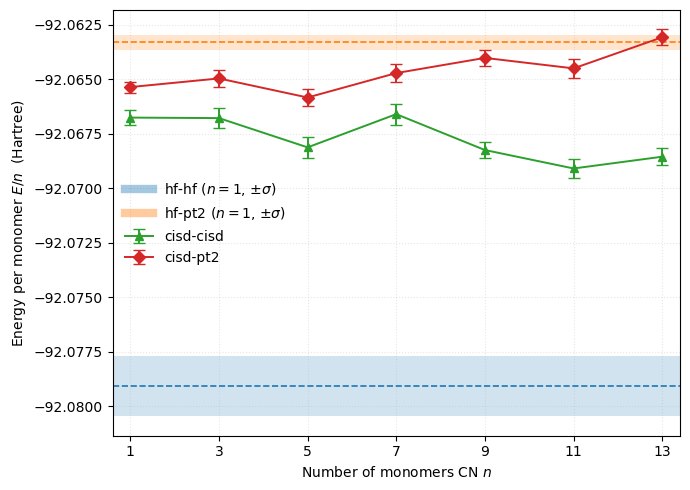

In [27]:
# ---- plotting options --------------------------------------------------------
show    = {"hf-hf": True, "hf-pt2": True, "cisd-cisd": True, "cisd-pt2": True}
as_band = ["hf-hf", "hf-pt2"]      # size-extensive: draw as a horizontal E/n +- sigma band
# ------------------------------------------------------------------------------

style = {name: dict(color=f"C{i}", marker=m)
         for i, (name, m) in enumerate(zip(table, ["o", "s", "^", "D"]))}

fig, ax = plt.subplots(figsize=(7, 5))
for name, on in show.items():
    if not on:
        continue
    E, dE = table[name]
    e_pm, d_pm = E / n, dE / n
    color = style[name]["color"]

    if name in as_band:
        k = np.flatnonzero(np.isfinite(e_pm))[0]     # reference point (here n=1)
        y, s = e_pm[k], d_pm[k]
        ax.axhspan(y - s, y + s, color=color, alpha=0.20, lw=0)
        ax.axhline(y, color=color, lw=1.2, ls="--")
        ax.plot([], [], color=color, lw=6, alpha=0.4,
                label=rf"{name} ($n={n[k]}$, $\pm\sigma$)")   # legend proxy
    else:
        ax.errorbar(n, e_pm, yerr=d_pm, ms=6, lw=1.4, capsize=4,
                    label=name, **style[name])

ax.set_xlabel(r"Number of monomers CN $n$")
ax.set_ylabel(r"Energy per monomer $E/n$  (Hartree)")
ax.set_xlim(n.min() - 0.4, n.max() + 0.4)
ax.set_xticks(n)
ax.grid(alpha=0.3, ls=":")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [8]:
# CO HEAT STO6G
data = '''
#n          hf-hf              hf-pt2              cisd-cisd           cisd-pt2
 1  -112.44812 0.00117  -112.43844 0.00037  -112.44255 0.00015  -112.44253 0.00016
 3          n/a                 n/a         -337.32760 0.00059  -337.32760 0.00048
 5          n/a                 n/a         -562.21161 0.00107  -562.21030 0.00074
 7          n/a                 n/a         -787.09606 0.00158  -787.09540 0.00117
 9          n/a                 n/a        -1011.98406 0.00186 -1011.97837 0.00165
'''


def read_table(text):
    """Return n and {method: (energies, errors)}; 'n/a' and missing -> nan."""
    lines = [l for l in text.strip('\n').split('\n') if l.strip(' #')]
    header, rows = lines[0], lines[1:]

    cols   = [(m.group(), m.start()) for m in re.finditer(r'\S+', header)][1:]
    names  = [name for name, _ in cols]
    anchor = np.array([pos for _, pos in cols])

    n, table = [], {name: [] for name in names}
    for line in rows:
        line = line.replace('#', ' ', 1)           # uncomment, preserving alignment
        toks = [(m.group(), m.start()) for m in re.finditer(r'\S+', line)]
        n.append(int(toks[0][0]))

        row, i = {name: (np.nan, np.nan) for name in names}, 1
        while i < len(toks):
            tok, pos = toks[i]
            col = names[np.abs(anchor - pos).argmin()]   # match by column position
            try:
                val = float(tok)
            except ValueError:                            # 'n/a', '--', etc.
                i += 1
                continue
            row[col] = (val, float(toks[i + 1][0]))
            i += 2
        for name in names:
            table[name].append(row[name])

    return np.array(n), {name: (np.array([v for v, _ in p]), np.array([e for _, e in p]))
                         for name, p in table.items()}

n, table = read_table(data)

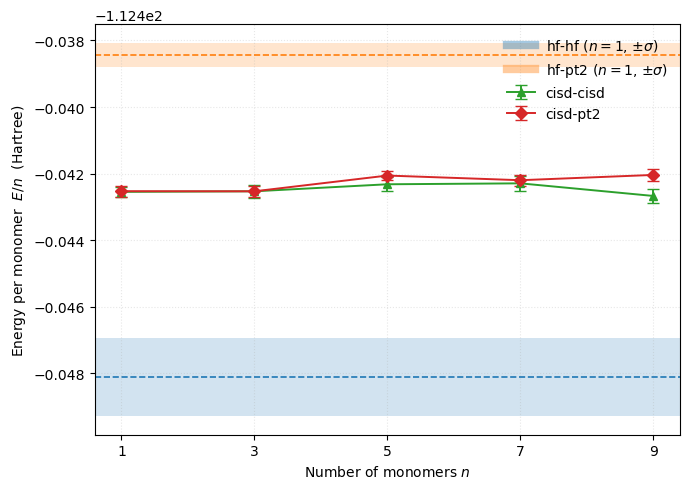

In [11]:
# ---- plotting options --------------------------------------------------------
show    = {"hf-hf": True, "hf-pt2": True, "cisd-cisd": True, "cisd-pt2": True}
as_band = ["hf-hf", "hf-pt2"]      # size-extensive: draw as a horizontal E/n +- sigma band
# ------------------------------------------------------------------------------

style = {name: dict(color=f"C{i}", marker=m)
         for i, (name, m) in enumerate(zip(table, ["o", "s", "^", "D"]))}

fig, ax = plt.subplots(figsize=(7, 5))
for name, on in show.items():
    if not on:
        continue
    E, dE = table[name]
    e_pm, d_pm = E / n, dE / n
    color = style[name]["color"]

    if name in as_band:
        k = np.flatnonzero(np.isfinite(e_pm))[0]     # reference point (here n=1)
        y, s = e_pm[k], d_pm[k]
        ax.axhspan(y - s, y + s, color=color, alpha=0.20, lw=0)
        ax.axhline(y, color=color, lw=1.2, ls="--")
        ax.plot([], [], color=color, lw=6, alpha=0.4,
                label=rf"{name} ($n={n[k]}$, $\pm\sigma$)")   # legend proxy
    else:
        ax.errorbar(n, e_pm, yerr=d_pm, ms=6, lw=1.4, capsize=4,
                    label=name, **style[name])

ax.set_xlabel(r"Number of monomers $n$")
ax.set_ylabel(r"Energy per monomer  $E/n$  (Hartree)")
ax.set_xlim(n.min() - 0.4, n.max() + 0.4)
ax.set_xticks(n)
ax.grid(alpha=0.3, ls=":")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [39]:
# NO HEAT STO6G
data = '''
#n          hf-hf              hf-pt2              cisd-cisd           cisd-pt2
 1    -128.88856 0.00064  -128.89055 0.00016   -128.89228 0.00008   -128.89226 0.00008
 3          n/a                 n/a            -386.67346 0.00056   -386.67677 0.00038
 5          n/a                 n/a            -644.45184 0.00087   -644.45800 0.00054
 7          n/a                 n/a            -902.22790 0.00160   -902.24112 0.00113
 9          n/a                 n/a           -1160.00845 0.00136  -1160.02245 0.00121 
 15         n/a                 n/a           -1933.34131 0.00241  -1933.36991 0.00220
'''

n, table = read_table(data)

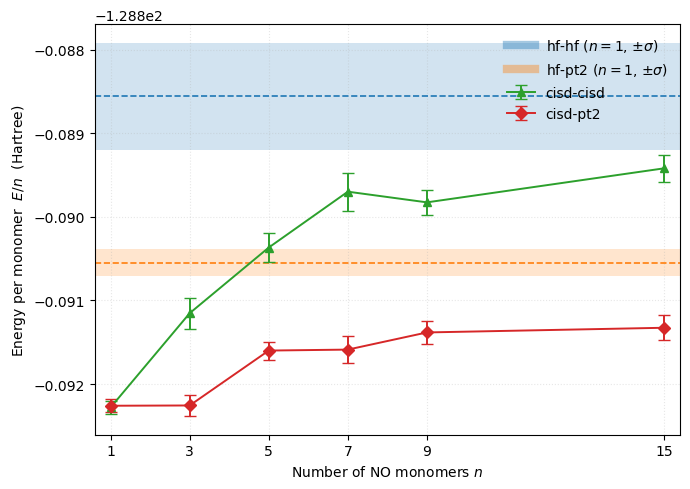

In [40]:
# ---- plotting options --------------------------------------------------------
show    = {"hf-hf": True, "hf-pt2": True, "cisd-cisd": True, "cisd-pt2": True}
as_band = ["hf-hf", "hf-pt2"]      # size-extensive: draw as a horizontal E/n +- sigma band
# ------------------------------------------------------------------------------

style = {name: dict(color=f"C{i}", marker=m)
         for i, (name, m) in enumerate(zip(table, ["o", "s", "^", "D"]))}

fig, ax = plt.subplots(figsize=(7, 5))
for name, on in show.items():
    if not on:
        continue
    E, dE = table[name]
    e_pm, d_pm = E / n, dE / n
    color = style[name]["color"]

    if name in as_band:
        k = np.flatnonzero(np.isfinite(e_pm))[0]     # reference point (here n=1)
        y, s = e_pm[k], d_pm[k]
        ax.axhspan(y - s, y + s, color=color, alpha=0.20, lw=0)
        ax.axhline(y, color=color, lw=1.2, ls="--")
        ax.plot([], [], color=color, lw=6, alpha=0.4,
                label=rf"{name} ($n={n[k]}$, $\pm\sigma$)")   # legend proxy
    else:
        ax.errorbar(n, e_pm, yerr=d_pm, ms=6, lw=1.4, capsize=4,
                    label=name, **style[name])

ax.set_xlabel(r"Number of NO monomers $n$")
ax.set_ylabel(r"Energy per monomer  $E/n$  (Hartree)")
ax.set_xlim(n.min() - 0.4, n.max() + 0.4)
ax.set_xticks(n)
ax.grid(alpha=0.3, ls=":")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()